## 1. Chargement et exploration des codes communes
Généralement, dans les fichiers DVF, le code commune se trouve sous deux formes : le Code INSEE (5 chiffres) ou une combinaison du Code Département et du Code Commune (3 chiffres). Pour l'INSEE, c'est le code à 5 chiffres qui te servira de clé de jointure.

In [24]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# Chargement du fichier prêt pour le ML
df_dvf = pd.read_csv('dvf_clean_model_ready.csv')

print(f"Fichier ML chargé : {df_dvf.shape[0]} lignes.")

Fichier ML chargé : 4640555 lignes.


In [25]:
print(df_dvf.info())

<class 'pandas.DataFrame'>
RangeIndex: 4640555 entries, 0 to 4640554
Data columns (total 14 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   surface_reelle_bati        float64
 1   nombre_pieces_principales  int64  
 2   surface_terrain            float64
 3   valeur_fonciere            float64
 4   annee                      int64  
 5   mois                       int64  
 6   code_departement           int64  
 7   longitude                  float64
 8   latitude                   float64
 9   is_maison                  int64  
 10  is_neuf                    int64  
 11  anciennete_mois            int64  
 12  commune_prix_m2            float64
 13  commune_volume             int64  
dtypes: float64(6), int64(8)
memory usage: 495.7 MB
None


In [26]:
import pandas as pd

df = pd.read_csv("BPE24.csv", sep=";")
# Aperçu rapide
print(df.info())

C:\Users\carine\AppData\Local\Temp\ipykernel_9660\3287533868.py:3: DtypeWarning: Columns (0: DEPCOM, 1: DEP, 2: QUALI_IRIS, 3: QUALI_QP2024, 4: QUALI_QVA, 5: QUALI_ZUS, 6: EPCI, 7: UU2020, 8: BV2022, 9: AAV2020) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("BPE24.csv", sep=";")


<class 'pandas.DataFrame'>
RangeIndex: 2827407 entries, 0 to 2827406
Data columns (total 89 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   AN                        int64  
 1   NOMRS                     str    
 2   CNOMRS                    str    
 3   NUMVOIE                   float64
 4   INDREP                    str    
 5   TYPVOIE                   str    
 6   LIBVOIE                   str    
 7   CADR                      str    
 8   CODPOS                    float64
 9   DEPCOM                    object 
 10  DEP                       object 
 11  REG                       int64  
 12  LIBCOM                    str    
 13  DOM                       str    
 14  SDOM                      str    
 15  TYPEQU                    str    
 16  SIRET                     float64
 17  STATUT_DIFFUSION          str    
 18  CANTINE                   str    
 19  INTERNAT                  str    
 20  RPI                       str    
 

In [27]:
# On regarde les 10 premières lignes pour nos codes cibles
# Pour voir si le nom de l'établissement correspond à ce qu'on attend
check_ecoles = df[df['TYPEQU'].isin(['C101', 'C201', 'C301', 'C501'])][['TYPEQU', 'NOMRS', 'LIBCOM', 'CANTINE']]
print(check_ecoles.head(15))

     TYPEQU                                             NOMRS         LIBCOM  \
2037   C201                                    COLLEGE RAIZET     LES ABYMES   
2038   C201                           COLLEGE ALEXANDRE ISAAC     LES ABYMES   
2039   C201                          COLLEGE SAINT-JOHN PERSE     LES ABYMES   
2040   C201                         COLLEGE AURELIE LAMBOURDE     LES ABYMES   
2041   C201       COLLEGE CITE SCOLAIRE D'EXCELLENCE SPORTIVE     LES ABYMES   
2042   C201        ECOLE SECONDAIRE PRIVEE FLAMBOYANT PREMIER     LES ABYMES   
2043   C301         LYCEE GENERAL ET TECHNOLOGIQUE BAIMBRIDGE     LES ABYMES   
2044   C301  LPO LYCEE DES METIERS CHEVALIER DE SAINT-GEORGES     LES ABYMES   
2045   C301        LYCEE GENERAL ET TECHNOLOGIQUE FELIX PROTO     LES ABYMES   
2046   C301     LYCEE GENERAL ET TECHNOLOGIQUE JARDIN D'ESSAI     LES ABYMES   
2961   C201                             COLLEGE FERNAND BALIN  ANSE-BERTRAND   
5041   C201                  COLLEGE PRI

In [28]:
# Liste des colonnes critiques pour notre stratégie
cols_to_check = ['TYPEQU', 'DEPCOM', 'CANTINE', 'INTERNAT', 'LONGITUDE', 'LATITUDE']

# Calcul du pourcentage de manquants
missing_pct = df[cols_to_check].isnull().sum() / len(df) * 100
print("--- Pourcentage de valeurs manquantes ---")
print(missing_pct)

--- Pourcentage de valeurs manquantes ---
TYPEQU       0.000000
DEPCOM       0.000000
CANTINE      0.000000
INTERNAT     0.000000
LONGITUDE    3.702332
LATITUDE     3.702332
dtype: float64


In [29]:
# Fréquence de chaque code équipement
print(df['TYPEQU'].value_counts().loc[lambda x : x.index.str.startswith('C')])

TYPEQU
C108    21188
C109    14984
C107    12844
C610     9065
C201     7509
C301     2819
C302     1393
C410     1357
C409     1183
C701      825
C303      817
C305      744
C501      694
C509      568
C403      523
C702      417
C502      394
C603      391
C503      321
C504      282
C401      272
C604      113
C304      111
C602       86
C505       20
Name: count, dtype: int64


In [30]:
print("Valeurs uniques pour CANTINE :", df['CANTINE'].unique())
print("Valeurs uniques pour INTERNAT :", df['INTERNAT'].unique())

Valeurs uniques pour CANTINE : <StringArray>
['_Z', '1', '_U', '0']
Length: 4, dtype: str
Valeurs uniques pour INTERNAT : <StringArray>
['_Z', '0', '_U', '1']
Length: 4, dtype: str


## Nettoyage de la colonne CANTINE et Internat
Comme nous l'avons vu, on simplifie l'information pour le modèle : seul le 1 (présence confirmée) est conservé comme positif

In [31]:
# Conversion en numérique : 1 reste 1, tout le reste devient 0
df['CANTINE_NUM'] = df['CANTINE'].apply(lambda x: 1 if x == '1' else 0)

# On fait la même chose pour l'INTERNAT si tu comptes l'utiliser
df['INTERNAT_NUM'] = df['INTERNAT'].apply(lambda x: 1 if x == '1' else 0)

## Définition des Catégories Scolaires


In [32]:
import pandas as pd
import numpy as np
# 1. On définit le mapping des codes TYPEQU vers nos catégories
mapping_ecoles = {
    # Primaire
    'C101': 'PRIMAIRE', 'C104': 'PRIMAIRE', 'C105': 'PRIMAIRE', 
    'C108': 'PRIMAIRE', 'C109': 'PRIMAIRE', 'C107': 'PRIMAIRE',
    # Secondaire
    'C201': 'COLLEGE', 
    'C301': 'LYCEE', 'C302': 'LYCEE', 'C303': 'LYCEE', 'C304': 'LYCEE', 'C305': 'LYCEE',
    # Supérieur
    'C501': 'SUPERIEUR', 'C502': 'SUPERIEUR', 'C503': 'SUPERIEUR', 
    'C504': 'SUPERIEUR', 'C505': 'SUPERIEUR', 'C601': 'SUPERIEUR'
}

# 2. Nettoyage des colonnes binaires (Cantine / Internat)
# On transforme '1' en 1, et tout le reste (_U, _Z, 0) en 0
df['CANTINE_NUM'] = df['CANTINE'].apply(lambda x: 1 if x == '1' else 0)
df['INTERNAT_NUM'] = df['INTERNAT'].apply(lambda x: 1 if x == '1' else 0)

# 3. Création de la catégorie scolaire
df['CAT_SCOLAIRE'] = df['TYPEQU'].map(mapping_ecoles)

# 4. Création de la distinction Public / Privé
# On crée une étiquette précise (ex: COLLEGE_PRIVE)
def label_secteur(row):
    if pd.isna(row['CAT_SCOLAIRE']):
        return np.nan
    secteur = "PRIVE" if row['SECT'] == 'PR' else "PUBLIC"
    return f"{row['CAT_SCOLAIRE']}_{secteur}"

df['CAT_DETAIL_SCOLAIRE'] = df.apply(label_secteur, axis=1)

# 5. On crée un dataframe dédié aux écoles pour les calculs futurs
# On ne garde que les lignes qui ont une catégorie et des coordonnées
df_scolaire = df.dropna(subset=['CAT_DETAIL_SCOLAIRE', 'LATITUDE', 'LONGITUDE']).copy()

print(df_scolaire['CAT_DETAIL_SCOLAIRE'].value_counts())

CAT_DETAIL_SCOLAIRE
PRIMAIRE_PUBLIC     43003
PRIMAIRE_PRIVE       5784
COLLEGE_PUBLIC       5304
LYCEE_PUBLIC         3343
LYCEE_PRIVE          2517
COLLEGE_PRIVE        2179
SUPERIEUR_PUBLIC     1296
SUPERIEUR_PRIVE       415
Name: count, dtype: int64


### Categorie privé

In [33]:
# 1. On crée une colonne binaire pour identifier le privé
df_scolaire['is_prive'] = df_scolaire['SECT'].apply(lambda x: 1 if x == 'PR' else 0)

# 2. On agrège par commune (DEPCOM)
stats_communes = df_scolaire.groupby('DEPCOM').agg(
    nb_total_ecoles=('CAT_SCOLAIRE', 'count'),
    nb_prive=('is_prive', 'sum')
).reset_index()

# 3. On calcule le taux
stats_communes['taux_ecoles_privees'] = stats_communes['nb_prive'] / stats_communes['nb_total_ecoles']

# 4. On gère les communes sans écoles (si besoin)
stats_communes['taux_ecoles_privees'] = stats_communes['taux_ecoles_privees'].fillna(0)

## référentiel par commune

In [34]:
# 1. On crée le tableau croisé (Pivot Table) pour avoir les comptes par commune
# On utilise DEPCOM (Code INSEE) comme clé
com_stats = df_scolaire.pivot_table(
    index='DEPCOM', 
    columns='CAT_DETAIL_SCOLAIRE', 
    values='TYPEQU', 
    aggfunc='count', 
    fill_value=0
).reset_index()

# 2. On calcule les totaux pour les taux
com_stats['total_ecoles'] = com_stats[['PRIMAIRE_PUBLIC', 'PRIMAIRE_PRIVE', 'COLLEGE_PUBLIC', 'COLLEGE_PRIVE', 'LYCEE_PUBLIC', 'LYCEE_PRIVE']].sum(axis=1)
com_stats['total_prive'] = com_stats[['PRIMAIRE_PRIVE', 'COLLEGE_PRIVE', 'LYCEE_PRIVE']].sum(axis=1)

# 3. Création de la variable Taux de Privé
# On utilise une division sécurisée (si total_ecoles == 0)
com_stats['taux_ecoles_privees'] = np.where(
    com_stats['total_ecoles'] > 0, 
    com_stats['total_prive'] / com_stats['total_ecoles'], 
    0
)

# 4. On ne garde que les colonnes les plus impactantes pour ne pas surcharger le modèle
cols_to_keep = ['DEPCOM', 'taux_ecoles_privees', 'PRIMAIRE_PUBLIC', 'COLLEGE_PUBLIC', 'LYCEE_PUBLIC', 'SUPERIEUR_PUBLIC']
com_stats_final = com_stats[cols_to_keep].copy()

## Recap colonne éducatives

--- RÉCAPITULATIF DES VARIABLES ÉDUCATIVES PAR COMMUNE ---
CAT_DETAIL_SCOLAIRE  taux_ecoles_privees  PRIMAIRE_PUBLIC  COLLEGE_PUBLIC  \
count                       21482.000000     21482.000000    21482.000000   
mean                            0.085027         2.001815        0.246904   
std                             0.207240         4.728842        0.810308   
min                             0.000000         0.000000        0.000000   
25%                             0.000000         1.000000        0.000000   
50%                             0.000000         1.000000        0.000000   
75%                             0.000000         2.000000        0.000000   
max                             1.000000       191.000000       24.000000   

CAT_DETAIL_SCOLAIRE  LYCEE_PUBLIC  SUPERIEUR_PUBLIC  
count                21482.000000       21482.00000  
mean                     0.155619           0.06033  
std                      0.834712           0.80093  
min                      0.0000

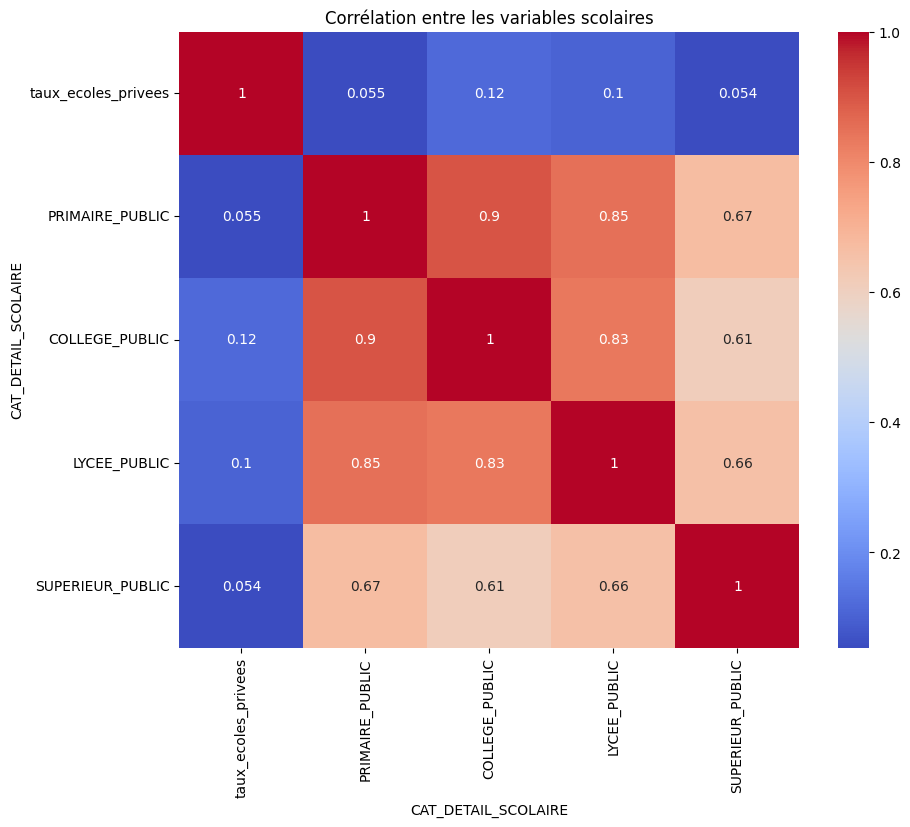

In [35]:
# 1. Aperçu des statistiques descriptives
print("--- RÉCAPITULATIF DES VARIABLES ÉDUCATIVES PAR COMMUNE ---")
print(com_stats_final.describe())

# 2. Vérification des "Zéros" (Communes sans équipements)
zero_counts = (com_stats_final == 0).sum()
print("\n--- NOMBRE DE COMMUNES SANS ÉQUIPEMENTS ---")
print(zero_counts)

# 3. Vérification de la corrélation
# Si deux colonnes sont corrélées à 0.99, on peut en supprimer une.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(com_stats_final.drop(columns=['DEPCOM']).corr(), annot=True, cmap='coolwarm')
plt.title("Corrélation entre les variables scolaires")
plt.show()

In [36]:
# On crée le dataset final pour la jointure
com_stats_clean = pd.DataFrame()
com_stats_clean['DEPCOM'] = com_stats['DEPCOM']

# 1. La variable de "Standing" (Indépendante)
com_stats_clean['taux_prive'] = com_stats['taux_ecoles_privees']

# 2. La variable de "Masse" (Somme des corrélés)
com_stats_clean['poids_scolaire_public'] = (
    com_stats['PRIMAIRE_PUBLIC'] + 
    com_stats['COLLEGE_PUBLIC'] + 
    com_stats['LYCEE_PUBLIC']
)

# 3. La variable "Profil Étudiant" (Binaire)
com_stats_clean['has_superieur'] = (com_stats['SUPERIEUR_PUBLIC'] > 0).astype(int)

# Vérification finale
print(com_stats_clean.head())

  DEPCOM  taux_prive  poids_scolaire_public  has_superieur
0   1001    0.000000                      1              0
1   1004    0.181818                      9              0
2   1005    0.000000                      1              0
3   1007    0.000000                      2              0
4   1008    0.000000                      1              0


## Préparation des points de services (BPE)
On filtre les équipements par catégorie en s'assurant qu'ils ont bien des coordonnées GPS.

In [37]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# 1. On prépare un sous-ensemble BPE propre avec coordonnées
# On utilise ton dataframe 'df' pour la BPE
df_bpe_geo = df.dropna(subset=['LATITUDE', 'LONGITUDE']).copy()

# 2. On définit les groupes de coordonnées (en Radians pour le calcul Haversine)
def get_coords_rad(df_subset):
    return np.deg2rad(df_subset[['LATITUDE', 'LONGITUDE']].values)

# On prépare les cibles
coords_primaire = get_coords_rad(df_bpe_geo[df_bpe_geo['CAT_SCOLAIRE'] == 'PRIMAIRE'])
coords_college  = get_coords_rad(df_bpe_geo[df_bpe_geo['CAT_SCOLAIRE'] == 'COLLEGE'])
coords_lycee    = get_coords_rad(df_bpe_geo[df_bpe_geo['CAT_SCOLAIRE'] == 'LYCEE'])
coords_superieur = get_coords_rad(df_bpe_geo[df_bpe_geo['CAT_SCOLAIRE'] == 'SUPERIEUR'])
coords_prive    = get_coords_rad(df_bpe_geo[df_bpe_geo['SECT'] == 'PR'])

## Calcul des distances pour le fichier DVF
On applique le calcul sur ton fichier de ventes 

In [38]:
# 1. On identifie les lignes DVF qui ont bien des coordonnées (on évite les NaN)
mask_geo = df_dvf['latitude'].notna() & df_dvf['longitude'].notna()

# 2. On prépare les coordonnées DVF valides en Radians
dvf_coords_valid = np.deg2rad(df_dvf.loc[mask_geo, ['latitude', 'longitude']].values)

def calculer_distance_safe(target_coords_rad, source_coords_rad, total_length, mask):
    # Si la cible est vide (ex: pas d'écoles sup), on renvoie des NaN ou une valeur par défaut
    if len(target_coords_rad) == 0:
        return np.full(total_length, np.nan)
    
    # Création de l'arbre spatial
    tree = BallTree(target_coords_rad, metric='haversine')
    
    # Calcul uniquement pour les lignes valides
    dist_valid, _ = tree.query(source_coords_rad, k=1)
    
    # On prépare le vecteur final (rempli de NaN par défaut)
    result = np.full(total_length, np.nan)
    # On injecte les distances calculées là où on avait des coordonnées
    result[mask] = dist_valid.flatten() * 6371
    return result

# 3. Application des calculs
print("Calcul des distances (version sans NaN) en cours...")

total = len(df_dvf)
df_dvf['dist_primaire'] = calculer_distance_safe(coords_primaire, dvf_coords_valid, total, mask_geo)
df_dvf['dist_college']  = calculer_distance_safe(coords_college, dvf_coords_valid, total, mask_geo)
df_dvf['dist_lycee']    = calculer_distance_safe(coords_lycee, dvf_coords_valid, total, mask_geo)
df_dvf['dist_superieur'] = calculer_distance_safe(coords_superieur, dvf_coords_valid, total, mask_geo)
df_dvf['dist_prive']    = calculer_distance_safe(coords_prive, dvf_coords_valid, total, mask_geo)

# 4. Optionnel : Remplacer les NaN finaux par la médiane pour ne pas bloquer XGBoost
cols_dist = ['dist_primaire', 'dist_college', 'dist_lycee', 'dist_superieur', 'dist_prive']
df_dvf[cols_dist] = df_dvf[cols_dist].fillna(df_dvf[cols_dist].median())

print("Terminé ! Les lignes sans coordonnées ont reçu la distance médiane.")

Calcul des distances (version sans NaN) en cours...
Terminé ! Les lignes sans coordonnées ont reçu la distance médiane.


## nouvelles colonnes 

In [39]:
cols_dist = ['dist_primaire', 'dist_college', 'dist_lycee', 'dist_superieur', 'dist_prive']
print(df_dvf[cols_dist].describe())

       dist_primaire  dist_college    dist_lycee  dist_superieur    dist_prive
count   4.640555e+06  4.640555e+06  4.640555e+06    4.640555e+06  4.640555e+06
mean    7.641407e-01  2.358856e+00  4.019197e+00    1.280253e+01  3.042260e+00
std     4.709167e+00  5.429690e+00  6.717774e+00    1.478073e+01  6.373808e+00
min     3.958066e-05  3.958066e-05  1.965538e-04    8.061899e-05  3.958066e-05
25%     1.987312e-01  4.458495e-01  5.825441e-01    1.554675e+00  3.967580e-01
50%     3.533210e-01  9.016714e-01  1.497434e+00    6.666068e+00  1.039550e+00
75%     6.994677e-01  3.232532e+00  5.964116e+00    2.084633e+01  3.807617e+00
max     2.410778e+02  2.431451e+02  2.429443e+02    2.642083e+02  2.463919e+02


## Création score de service ecole

In [40]:
# 1. Conversion pour optimiser la mémoire
cols_dist = ['dist_primaire', 'dist_college', 'dist_lycee', 'dist_superieur', 'dist_prive']
df_dvf[cols_dist] = df_dvf[cols_dist].astype('float32')

# 2. Création de variables binaires (très puissantes pour les arbres)
# "Est-ce que je peux aller à l'école à pied ?" (< 1km)
df_dvf['marche_primaire'] = (df_dvf['dist_primaire'] < 1.0).astype(int)

## Sauvegarde fichier dvf enrichi avec ecole

In [41]:
# Sauvegarde finale avec le nouveau nom
print("Sauvegarde en cours sous le nom 'dvf_bpe_ecoles.csv'...")

df_dvf.to_csv('dvf_bpe_ecoles.csv', index=False, sep=',', encoding='utf-8')

print("Fichier prêt ! Tu peux maintenant ouvrir ton nouveau Notebook pour le XGBoost.")

Sauvegarde en cours sous le nom 'dvf_bpe_ecoles.csv'...
Fichier prêt ! Tu peux maintenant ouvrir ton nouveau Notebook pour le XGBoost.
